In [1]:
from speclite import filters

import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroplan import Observer
import pytz

import seaborn as sns
import pandas as pd
from astropy.coordinates import AltAz
from datetime import datetime, timedelta
from astropy.time import TimezoneInfo


from astropy.coordinates import get_body
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

import matplotlib.patches  # make sure this is imported at the top

sns.set_theme("paper", style="white")

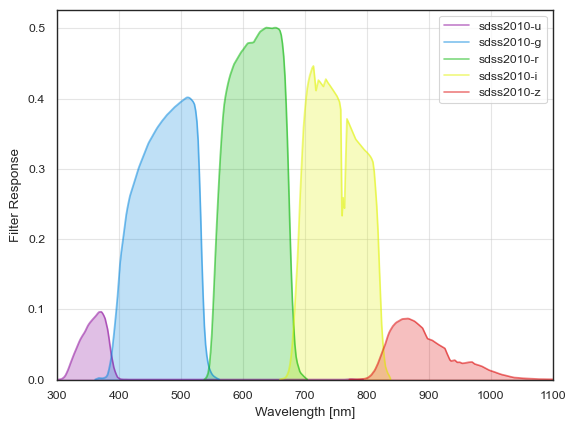

In [2]:
sdss = filters.load_filters('sdss2010-*')
filters.plot_filters(sdss, wavelength_limits=(300, 1100), wavelength_unit='nm')
plt.savefig("plots/sdss_filters.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
latitude = 51.84257
longitude = 5.83896
elevation = 60  # meters
timezone = pytz.timezone("Europe/Amsterdam")

observer = Observer(latitude=latitude * u.deg,
                    longitude=longitude * u.deg,
                    elevation=elevation * u.m,
                    timezone="Europe/Amsterdam",
                    name="Nijmegen")


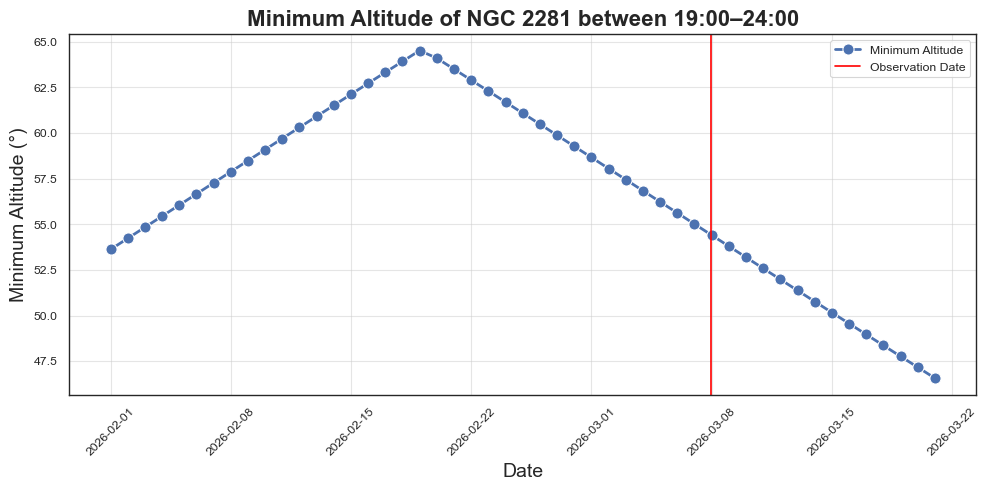

In [4]:
start_date = datetime(2026, 2, 1,  tzinfo=timezone)
end_date = datetime(2026, 3, 22,  tzinfo=timezone)
start_hour = 19
end_hour = 24

times = pd.date_range(
    start=start_date,
    end=end_date,
    freq="30min"
)
times = times[(times.hour >= start_hour) & (times.hour <= end_hour)]

frames = AltAz(obstime=times, location=observer.location, pressure=1010 * u.hPa)
ngc2281 = SkyCoord("06h48m16s", "+41d04m44s", frame="icrs").transform_to(frames)
altitudes = ngc2281.alt.degree

unique_dates = np.unique(times.date)
min_alt_per_day = [altitudes[times.date == d].min() for d in unique_dates]

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=unique_dates,
    y=min_alt_per_day,
    marker='o',
    linewidth=2,
    markersize=8,
    label="Minimum Altitude"
)
plt.axvline(datetime(2026, 3, 8,  tzinfo=timezone), color="red", label="Observation Date")

plt.xlabel("Date", fontsize=14)
plt.ylabel("Minimum Altitude (°)", fontsize=14)
plt.title(f"Minimum Altitude of NGC 2281 between {start_hour}:00–{end_hour}:00", fontsize=16, weight='bold')

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid()

# Save high-res figure
plt.savefig("plots/NGC2281_altitude_date.png", dpi=300, bbox_inches='tight')

plt.show()

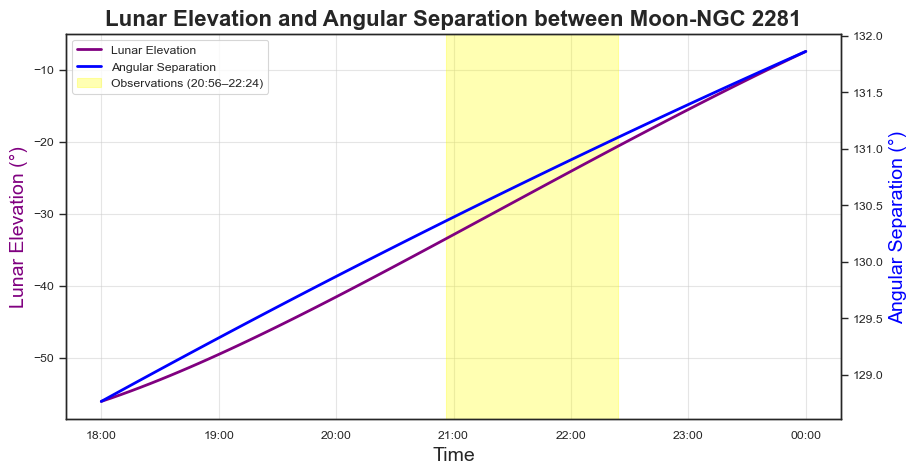

In [9]:
start_date = pd.Timestamp("2026-03-08 18:00:00", tz=timezone)
end_date   = pd.Timestamp("2026-03-09 00:00:00", tz=timezone)

obs_start = pd.Timestamp("2026-03-08 20:56:00", tz=timezone)
obs_end   = pd.Timestamp("2026-03-08 22:24:00", tz=timezone)

times = pd.date_range(start=start_date, end=end_date, freq="5min")

# --- Convert ONCE to Astropy time ---
times_utc = times.tz_convert("UTC")
times_astropy = Time(times_utc.to_numpy())
# --- AltAz frame ---
frame = AltAz(
    obstime=times_astropy,
    location=observer.location,
    pressure=1010 * u.hPa
)

# --- Target and Moon ---
ngc2281 = SkyCoord("06h48m16s", "+41d04m44s", frame="icrs").transform_to(frame)
moon = get_body('moon', times_astropy, location=observer.location).transform_to(frame)

moon_alt = moon.alt.deg
angular_sep = ngc2281.separation(moon).deg

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Lunar elevation ---
sns.lineplot(
    x=times,
    y=moon_alt,
    linewidth=2,
    color='purple',
    ax=ax1,
    label="Lunar Elevation",
    zorder=5,
    legend=False
)

ax1.set_ylabel("Lunar Elevation (°)", fontsize=14, color='purple')

# --- Observation window ---
ax1.axvspan(
    obs_start,
    obs_end,
    color='yellow',
    alpha=0.3,
    label='Observations (20:56–22:24)'
)

# --- Angular separation ---
ax2 = ax1.twinx()

sns.lineplot(
    x=times,
    y=angular_sep,
    linewidth=2,
    color='blue',
    ax=ax2,
    label="Angular Separation",
    zorder=5,
    legend=False
)

ax2.set_ylabel("Angular Separation (°)", fontsize=14, color='blue')

# --- FORCE axis consistency ---
xticks = pd.date_range(start_date, end_date, freq="1h")

# ax1.set_xlim(start_date, end_date)
# ax1.set_xticks(xticks)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone))

# --- Labels & title ---
ax1.set_xlabel("Time", fontsize=14)
plt.title(
    "Lunar Elevation and Angular Separation between Moon-NGC 2281",
    fontsize=16,
    weight='bold'
)

plt.xticks(rotation=45)

# --- Legend merging ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

pairs = list(zip(lines_1, labels_1))
patch = [(h, l) for h, l in pairs if isinstance(h, mpatches.Patch)]
line  = [(h, l) for h, l in pairs if not isinstance(h, mpatches.Patch)]

handles, labels = zip(*(line + list(zip(lines_2, labels_2)) + patch))
plt.legend(handles, labels, loc='upper left')

# --- Grid ---
ax1.grid()

# --- Save ---
plt.savefig("plots/NGC2281_moon_sep_alt.png", dpi=300, bbox_inches='tight')
plt.show()

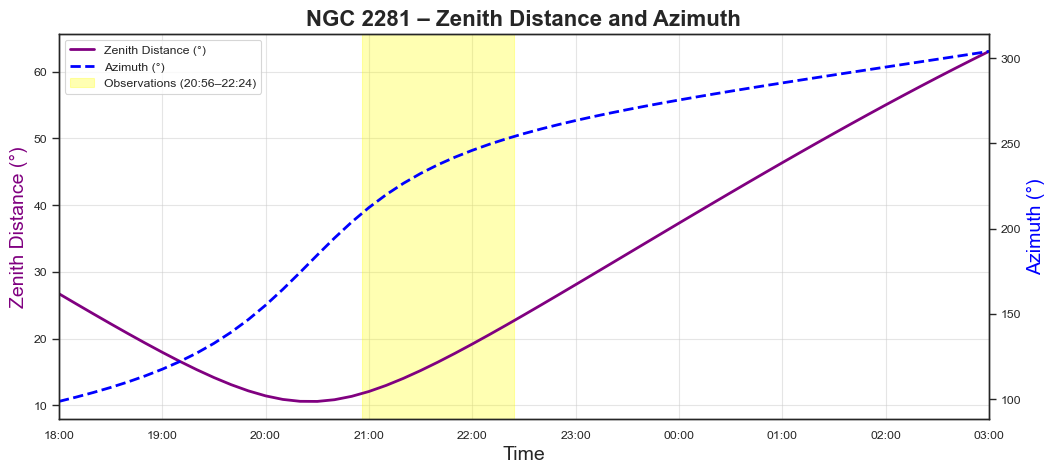

In [12]:
# -----------------------------
# NGC 2281 ZENITH DISTANCE + AZIMUTH
# -----------------------------

from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pytz
import matplotlib.patches as mpatches

# -----------------------------
# Observer
# -----------------------------
observer_location = EarthLocation(
    lat=52.1579 * u.deg,
    lon=5.388 * u.deg,
    height=12 * u.m
)

timezone = pytz.timezone("Europe/Amsterdam")

# -----------------------------
# Time (CONSISTENT WITH FIRST SCRIPT)
# -----------------------------
start_date = pd.Timestamp("2026-03-08 18:00:00", tz=timezone)
end_date   = pd.Timestamp("2026-03-09 03:00:00", tz=timezone)

times = pd.date_range(start=start_date, end=end_date, freq="10min")

# Convert ONCE to UTC → Astropy
times_utc = times.tz_convert("UTC")
times_astropy = Time(times_utc.to_numpy())

# -----------------------------
# Observation window
# -----------------------------
obs_start = pd.Timestamp("2026-03-08 20:56:00", tz=timezone)
obs_end   = pd.Timestamp("2026-03-08 22:24:00", tz=timezone)

# -----------------------------
# AltAz frame
# -----------------------------
frame = AltAz(
    obstime=times_astropy,
    location=observer_location,
    pressure=1010 * u.hPa
)

# -----------------------------
# Target
# -----------------------------
ngc2281 = SkyCoord(
    ra=102.825 * u.deg,
    dec=41.602 * u.deg,
    frame="icrs"
)

ngc2281_altaz = ngc2281.transform_to(frame)

alt = ngc2281_altaz.alt.deg
az  = ngc2281_altaz.az.deg

# -----------------------------
# Derived quantities
# -----------------------------
zenith_distance = 90 - alt
airmass = 1 / np.cos(np.radians(zenith_distance))  # optional

# -----------------------------
# Plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12, 5))

# Zenith distance
sns.lineplot(
    x=times,
    y=zenith_distance,
    linewidth=2,
    color='purple',
    ax=ax1,
    label="Zenith Distance (°)",
    legend=False
)

ax1.set_ylabel("Zenith Distance (°)", fontsize=14, color='purple')

# Observation window
ax1.axvspan(
    obs_start,
    obs_end,
    color='yellow',
    alpha=0.3,
    label='Observations (20:56–22:24)'
)

# Azimuth (twin axis)
ax2 = ax1.twinx()

sns.lineplot(
    x=times,
    y=az,
    linewidth=2,
    linestyle='--',
    color='blue',
    ax=ax2,
    label="Azimuth (°)",
    legend=False
)

ax2.set_ylabel("Azimuth (°)", fontsize=14, color='blue')

# -----------------------------
# Axis FIX (CRUCIAL)
# -----------------------------
xticks = pd.date_range(start_date, end_date, freq="1h")

ax1.set_xlim(start_date, end_date)
ax1.set_xticks(xticks)

ax1.xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M', tz=timezone)
)

# -----------------------------
# Labels & title
# -----------------------------
ax1.set_xlabel("Time", fontsize=14)

plt.title(
    "NGC 2281 – Zenith Distance and Azimuth",
    fontsize=16,
    weight='bold'
)

plt.xticks(rotation=45)

# -----------------------------
# Legend merging (clean)
# -----------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

pairs = list(zip(lines_1, labels_1))
patch = [(h, l) for h, l in pairs if isinstance(h, mpatches.Patch)]
line  = [(h, l) for h, l in pairs if not isinstance(h, mpatches.Patch)]

handles, labels = zip(*(line + list(zip(lines_2, labels_2)) + patch))
plt.legend(handles, labels, loc='upper left')

# -----------------------------
# Final touches
# -----------------------------
ax1.grid()

plt.savefig(
    "plots/NGC2281_zenith_azimuth.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()